<a href="https://colab.research.google.com/github/rahulsanjel/Aritificialintelligence/blob/main/2330993_RahulSharma_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part III – Language Tasks
## Sentiment Analysis: Sarcasm Detection in News Headlines

---

**Dataset:** Sarcastic Headlines Dataset  
**Task:** Binary Text Classification using Simple RNN, LSTM, and LSTM with Word2Vec  
**Total Records:** 28,619 news headlines  
**Classes:** Sarcastic (1) / Not Sarcastic (0)

---

## Step 0: Install Required Libraries

In [3]:
# Install required libraries
# Run this cell only once, then restart runtime if prompted
!pip install numpy==1.23.5 -q
!pip install gensim -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 77.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 58.7 MB/s eta 0:00:00


##Step 1: Dataset Loading & Overview

This step loads the dataset and gives a quick overview of its structure, including the number of rows, columns, and sample records. It helps us understand what kind of data we are working with before applying any preprocessing or modeling.

#Why is this important?

Understanding dataset structure is the first step in any machine learning task. It ensures that the data is loaded correctly and provides insight into the features available for analysis.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Word cloud
from wordcloud import WordCloud

print("All libraries imported successfully!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


All libraries imported successfully!


## Step 2: Load and Explore the Dataset

In [5]:
# Load dataset from Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [35]:
# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/Sarcasticdataset/sarcastic_headlines.csv')

# ── Dataset Overview ───────────────────────────────────────────────────────

print("=" * 60)
print("Dataset Loaded Successfully")
print("=" * 60)

print(f"Total Records : {len(df):,}")
print(f"Columns       : {df.columns.tolist()}")

print("\nPreview of First 10 Rows:")
print("-" * 60)

df.head(15)

Dataset Loaded Successfully
Total Records : 28,619
Columns       : ['headline', 'is_sarcastic']

Preview of First 10 Rows:
------------------------------------------------------------


,headline,is_sarcastic
0,thirtysomething scientists unveil doomsday clo...,1
1,dem rep. totally nails why congress is falling...,0
2,eat your veggies: 9 deliciously different recipes,0
3,inclement weather prevents liar from getting t...,1
4,mother comes pretty close to using word 'strea...,1
5,my white inheritance,0
6,5 ways to file your taxes with less stress,0
7,richard branson's global-warming donation near...,1
8,shadow government getting too large to meet in...,1
9,lots of parents know this scenario,0


##Step 2: Data Cleaning (Duplicates & Missing Values)

This step removes duplicate rows and handles missing values in the dataset. Duplicate entries can bias the model, while missing values can cause errors or reduce performance.

##Why is this important?

Clean data ensures that the model learns from accurate and unique examples, improving reliability and performance.

In [37]:
# ── Missing Values Check ───────────────────────────────────────────────────

print("=" * 50)
print("Missing Values Report")
print("=" * 50)

missing = df.isnull().sum()
print(missing)

print("\n" + "=" * 50)

# ── Class Distribution ─────────────────────────────────────────────────────

print("Class Distribution")
print("=" * 50)

class_counts = df['is_sarcastic'].value_counts().sort_index()

print(class_counts)

print("\nDetailed Breakdown:")
print(f"Not Sarcastic (0): {class_counts.get(0, 0):,} headlines")
print(f"Sarcastic     (1): {class_counts.get(1, 0):,} headlines")

print("=" * 50)

Missing Values Report
headline        0
is_sarcastic    0
dtype: int64

Class Distribution
is_sarcastic
0    14985
1    13634
Name: count, dtype: int64

Detailed Breakdown:
Not Sarcastic (0): 14,985 headlines
Sarcastic     (1): 13,634 headlines


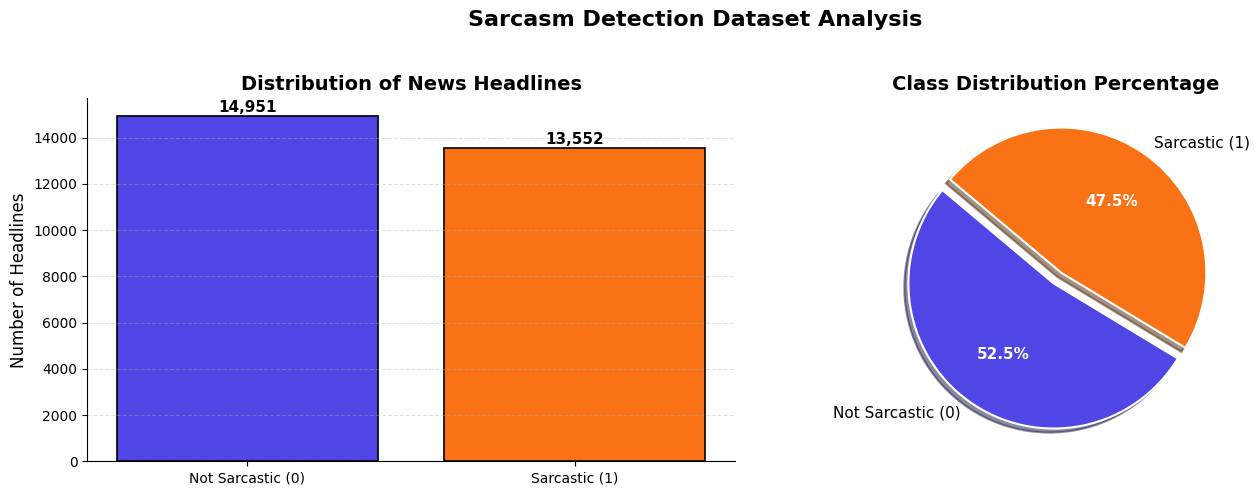

In [18]:
# Visualize class distribution with improved styling
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Modern color palette
colors = ['#4F46E5', '#F97316']   # Indigo & Orange

# Labels and counts
labels = ['Not Sarcastic (0)', 'Sarcastic (1)']
counts = df['is_sarcastic'].value_counts().sort_index()

# ── Bar Chart ────────────────────────────────────────────────────────────────
bars = axes[0].bar(
    labels,
    counts.values,
    color=colors,
    edgecolor='black',
    linewidth=1.2
)

axes[0].set_title('Distribution of News Headlines', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Headlines', fontsize=12)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# Remove top/right spines for cleaner look
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Add value labels
for bar in bars:
    height = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        height + 150,
        f'{height:,}',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

# ── Pie Chart ────────────────────────────────────────────────────────────────
wedges, texts, autotexts = axes[1].pie(
    counts.values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    explode=(0.03, 0.06),
    shadow=True,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    textprops={'fontsize': 11}
)

# Style percentage text
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

axes[1].set_title('Class Distribution Percentage', fontsize=14, fontweight='bold')

# Overall layout
plt.suptitle('Sarcasm Detection Dataset Analysis', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save and show
plt.savefig('class_distribution_improved.png', dpi=300, bbox_inches='tight')
plt.show()

Headline Length Statistics (in words):
count    28503.000000
mean        10.060871
std          3.385275
min          2.000000
25%          8.000000
50%         10.000000
75%         12.000000
max        151.000000
Name: headline_length, dtype: float64


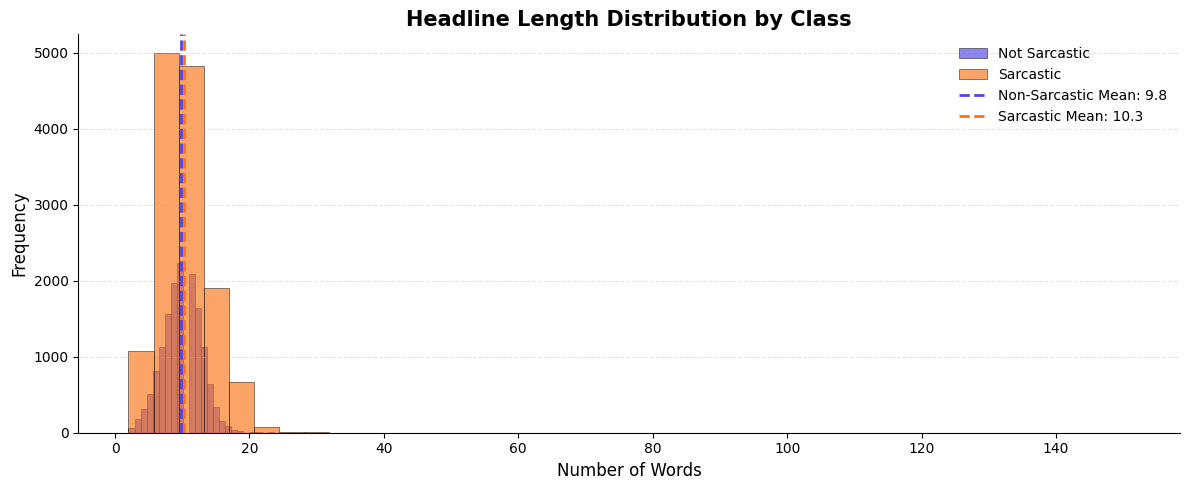

In [19]:
# ── Headline Length Analysis ────────────────────────────────────────────────

# Create headline length column
df['headline_length'] = df['headline'].apply(lambda x: len(str(x).split()))

# Display statistics
print("Headline Length Statistics (in words):")
print(df['headline_length'].describe())

# Separate classes
non_sarcastic = df[df['is_sarcastic'] == 0]['headline_length']
sarcastic = df[df['is_sarcastic'] == 1]['headline_length']

# Modern color palette
colors = ['#4F46E5', '#F97316']   # Indigo & Orange

# Create figure
plt.figure(figsize=(12, 5))

# Histogram plots
plt.hist(
    non_sarcastic,
    bins=40,
    alpha=0.65,
    label='Not Sarcastic',
    color=colors[0],
    edgecolor='black',
    linewidth=0.5
)

plt.hist(
    sarcastic,
    bins=40,
    alpha=0.65,
    label='Sarcastic',
    color=colors[1],
    edgecolor='black',
    linewidth=0.5
)

# Mean lines
plt.axvline(non_sarcastic.mean(), color=colors[0],
            linestyle='--', linewidth=2,
            label=f'Non-Sarcastic Mean: {non_sarcastic.mean():.1f}')

plt.axvline(sarcastic.mean(), color=colors[1],
            linestyle='--', linewidth=2,
            label=f'Sarcastic Mean: {sarcastic.mean():.1f}')

# Labels and title
plt.xlabel('Number of Words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Headline Length Distribution by Class',
          fontsize=15, fontweight='bold')

# Grid styling
plt.grid(axis='y', linestyle='--', alpha=0.35)

# Legend
plt.legend(frameon=False)

# Remove unnecessary borders
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Layout adjustment
plt.tight_layout()

# Save and show
plt.savefig('headline_length_improved.png',
            dpi=300,
            bbox_inches='tight')

plt.show()

Step 3: Text Preprocessing (clean_text function)

This step converts raw text into a clean and standardized format suitable for machine learning.

Operations performed:
Convert text to lowercase
Expand contractions (e.g., don't → do not)
Remove URLs, hashtags, mentions, numbers, and punctuation
Remove stopwords
Apply lemmatization (convert words to base form)
Why is this important?

Text data is noisy and inconsistent. Preprocessing removes unnecessary elements and ensures that only meaningful words are used for training.

In [22]:
# ── Dataset Cleaning & Text Preprocessing ──────────────────────────────────

# Display original dataset shape
print("=" * 60)
print("Original Dataset Shape:", df.shape)

# Check duplicate rows
duplicate_count = df.duplicated().sum()
print(f"\nDuplicate Rows Found: {duplicate_count:,}")

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Check missing values
print("\nMissing Values in Each Column:")
print(df.isnull().sum())

# Remove missing values
df.dropna(inplace=True)

# Display cleaned dataset shape
print("\nCleaned Dataset Shape:", df.shape)
print("=" * 60)

# ── NLP Initialization ─────────────────────────────────────────────────────

# Initialize stopwords and lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Expanded contractions dictionary
contractions = {
    "don't": "do not",
    "can't": "cannot",
    "won't": "will not",
    "it's": "it is",
    "i'm": "i am",
    "you're": "you are",
    "they're": "they are",
    "we're": "we are",
    "isn't": "is not",
    "wasn't": "was not",
    "aren't": "are not",
    "weren't": "were not",
    "haven't": "have not",
    "hasn't": "has not",
    "hadn't": "had not",
    "wouldn't": "would not",
    "couldn't": "could not",
    "shouldn't": "should not",
    "didn't": "did not",
    "doesn't": "does not",
    "that's": "that is",
    "there's": "there is",
    "what's": "what is"
}

# ── Text Cleaning Function ─────────────────────────────────────────────────

def clean_text(text):

    # Convert to lowercase
    text = str(text).lower()

    # Expand contractions
    for word, replacement in contractions.items():
        text = text.replace(word, replacement)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation and special characters
    text = re.sub(r'[^\w\s]', '', text)

    # Tokenization
    tokens = text.split()

    # Remove stopwords and apply lemmatization
    cleaned_tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 1
    ]

    # Join cleaned tokens
    return ' '.join(cleaned_tokens)

# ── Apply Text Cleaning ────────────────────────────────────────────────────

print("\nCleaning text data...")

df['cleaned'] = df['headline'].apply(clean_text)

print("Text preprocessing completed successfully!")

# ── Display Random Sample Results ──────────────────────────────────────────

comparison_df = (
    df[['headline', 'cleaned']]
    .sample(5, random_state=42)
    .rename(columns={
        'headline': 'Original Text',
        'cleaned': 'Cleaned Text'
    })
)

print("\nSample Text Cleaning Results:")

display(
    comparison_df.style
    .set_properties(**{
        'text-align': 'left',
        'white-space': 'pre-wrap',
        'padding': '8px'
    })
    .set_table_styles([
        {
            'selector': 'th',
            'props': [
                ('background-color', '#4F46E5'),
                ('color', 'white'),
                ('font-size', '12pt'),
                ('font-weight', 'bold'),
                ('text-align', 'center')
            ]
        },
        {
            'selector': 'td',
            'props': [
                ('border', '1px solid #dddddd'),
                ('font-size', '11pt')
            ]
        }
    ])
    .hide(axis='index')
)

Original Dataset Shape: (28503, 4)

Duplicate Rows Found: 0

Missing Values in Each Column:
headline           0
is_sarcastic       0
headline_length    0
cleaned            0
dtype: int64

Cleaned Dataset Shape: (28503, 4)

Cleaning text data...
Text preprocessing completed successfully!

Sample Text Cleaning Results:


Original Text,Cleaned Text
marco rubio nabs his first 2016 win in minnesota gop presidential caucus,marco rubio nabs first win minnesota gop presidential caucus
oops: hot mic broadcasts al roker going to the bathroom,oops hot mic broadcast al roker going bathroom
white house pretty sure uzbekistan diplomat stole a bunch of soap,white house pretty sure uzbekistan diplomat stole bunch soap
sean hannity informs building tenants about deep-state conspiracy forcing him to triple rent,sean hannity informs building tenant deepstate conspiracy forcing triple rent
switching to renewables will save millions of american lives,switching renewables save million american life


#Word Cloud Visualization

Word clouds are used to visually represent the most frequent words in sarcastic and non-sarcastic headlines. Larger words indicate higher frequency, helping us quickly understand key patterns in each class.

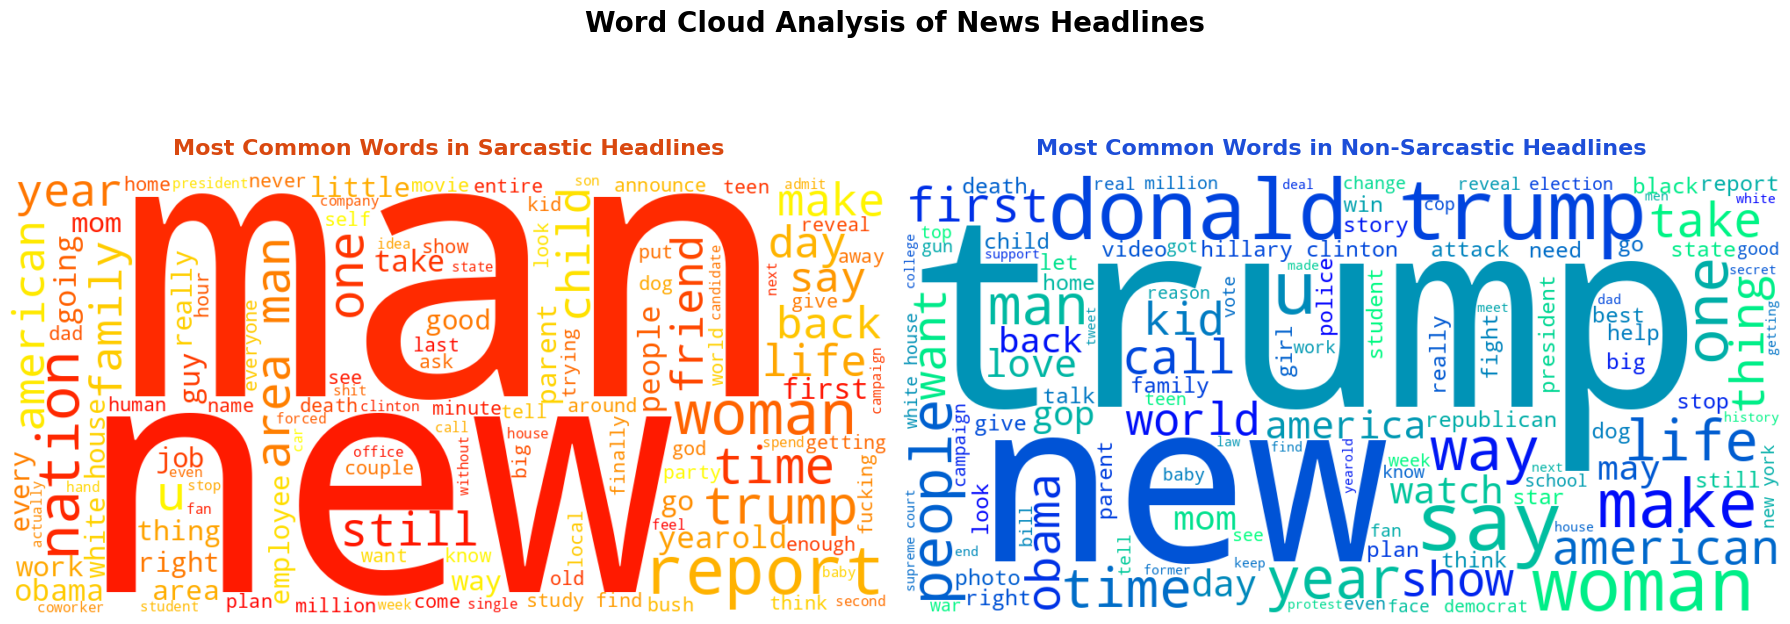

In [23]:
# ── Word Cloud Visualization ───────────────────────────────────────────────

# Combine text for each class
sarcastic_text = ' '.join(
    df[df['is_sarcastic'] == 1]['cleaned'].astype(str).tolist()
)

not_sarcastic_text = ' '.join(
    df[df['is_sarcastic'] == 0]['cleaned'].astype(str).tolist()
)

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Sarcastic Headlines Word Cloud ────────────────────────────────────────
wc1 = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    colormap='autumn',
    max_words=120,
    contour_width=1,
    contour_color='black'
).generate(sarcastic_text)

axes[0].imshow(wc1, interpolation='bilinear')
axes[0].axis('off')

axes[0].set_title(
    'Most Common Words in Sarcastic Headlines',
    fontsize=16,
    fontweight='bold',
    color='#D9480F',
    pad=15
)

# ── Non-Sarcastic Headlines Word Cloud ────────────────────────────────────
wc2 = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    colormap='winter',
    max_words=120,
    contour_width=1,
    contour_color='black'
).generate(not_sarcastic_text)

axes[1].imshow(wc2, interpolation='bilinear')
axes[1].axis('off')

axes[1].set_title(
    'Most Common Words in Non-Sarcastic Headlines',
    fontsize=16,
    fontweight='bold',
    color='#1D4ED8',
    pad=15
)

# Main title
plt.suptitle(
    'Word Cloud Analysis of News Headlines',
    fontsize=20,
    fontweight='bold',
    y=1.02
)

# Layout adjustments
plt.tight_layout()

# Save figure
plt.savefig(
    'improved_wordclouds.png',
    dpi=300,
    bbox_inches='tight'
)

# Display
plt.show()

## Step 6: Top Frequent Words Analysis

This step identifies and visualizes the most common words in each category using frequency counts.

## Why is this important?

It helps us understand which words are strongly associated with sarcastic and non-sarcastic headlines, giving insight into feature importance.

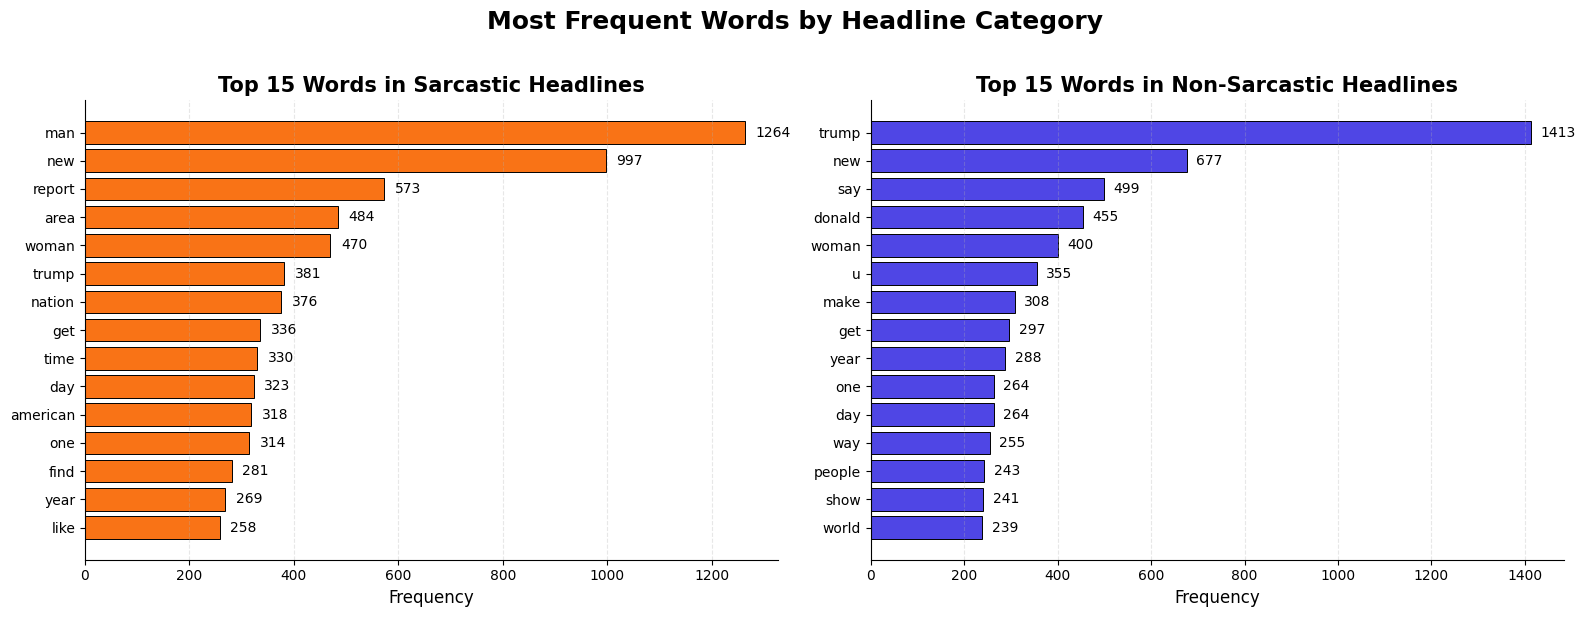

In [24]:
# ── Top Frequent Words Analysis ────────────────────────────────────────────

from collections import Counter

# Function to get top words
def top_words(text, n=15):
    all_words = text.split()
    return Counter(all_words).most_common(n)

# Get top words for each class
top_sarcastic = top_words(sarcastic_text)
top_not_sarcastic = top_words(not_sarcastic_text)

# Extract words and counts
words_s, counts_s = zip(*top_sarcastic)
words_n, counts_n = zip(*top_not_sarcastic)

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Modern colors
sarcastic_color = '#F97316'      # Orange
normal_color = '#4F46E5'         # Indigo

# ── Sarcastic Headlines ────────────────────────────────────────────────────
bars1 = axes[0].barh(
    words_s[::-1],
    counts_s[::-1],
    color=sarcastic_color,
    edgecolor='black',
    linewidth=0.7
)

axes[0].set_title(
    'Top 15 Words in Sarcastic Headlines',
    fontsize=15,
    fontweight='bold'
)

axes[0].set_xlabel('Frequency', fontsize=12)
axes[0].grid(axis='x', linestyle='--', alpha=0.3)

# Remove unnecessary spines
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Add labels
for bar in bars1:
    width = bar.get_width()
    axes[0].text(
        width + 20,
        bar.get_y() + bar.get_height()/2,
        f'{int(width)}',
        va='center',
        fontsize=10
    )

# ── Non-Sarcastic Headlines ────────────────────────────────────────────────
bars2 = axes[1].barh(
    words_n[::-1],
    counts_n[::-1],
    color=normal_color,
    edgecolor='black',
    linewidth=0.7
)

axes[1].set_title(
    'Top 15 Words in Non-Sarcastic Headlines',
    fontsize=15,
    fontweight='bold'
)

axes[1].set_xlabel('Frequency', fontsize=12)
axes[1].grid(axis='x', linestyle='--', alpha=0.3)

# Remove unnecessary spines
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Add labels
for bar in bars2:
    width = bar.get_width()
    axes[1].text(
        width + 20,
        bar.get_y() + bar.get_height()/2,
        f'{int(width)}',
        va='center',
        fontsize=10
    )

# Main title
plt.suptitle(
    'Most Frequent Words by Headline Category',
    fontsize=18,
    fontweight='bold',
    y=1.02
)

# Improve spacing
plt.tight_layout()

# Save figure
plt.savefig(
    'top_frequent_words_improved.png',
    dpi=300,
    bbox_inches='tight'
)

# Show plot
plt.show()

## Step 7: Train-Test Split

The dataset is split into training and testing sets (80% training, 20% testing). The model is trained on the training set and evaluated on unseen test data.

###Why is this important?

It ensures that the model is evaluated fairly and can generalize well to new, unseen data.

##Step 8: Tokenization

Text data is converted into numerical sequences using a tokenizer. Each word is assigned a unique integer index.

###Why is this important?

Neural networks cannot process text directly, so tokenization converts text into a numerical format suitable for modeling.

##Step 9: Padding Sequences

All sequences are padded or truncated to a fixed length based on the 85th percentile of sequence lengths.

###Why is this important?

Neural networks require uniform input size. Padding ensures that all sequences have the same length without losing important information.

In [25]:
# ── Train-Test Split ───────────────────────────────────────────────────────

# Features and target
X = df['cleaned'].values
y = df['is_sarcastic'].values

# Split dataset: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=21,
    stratify=y
)

# ── Display Dataset Information ────────────────────────────────────────────

print("=" * 55)
print("Dataset Split Summary")
print("=" * 55)

print(f"Total Samples      : {len(X):,}")
print(f"Training Samples   : {len(X_train):,}")
print(f"Testing Samples    : {len(X_test):,}")

print("\nTraining Ratio     : 80%")
print("Testing Ratio      : 20%")

# Class distribution check
train_distribution = pd.Series(y_train).value_counts(normalize=True) * 100
test_distribution = pd.Series(y_test).value_counts(normalize=True) * 100

print("\nClass Distribution (%)")
print("-" * 55)

print(f"Train -> Not Sarcastic : {train_distribution[0]:.2f}%")
print(f"Train -> Sarcastic     : {train_distribution[1]:.2f}%")

print()

print(f"Test  -> Not Sarcastic : {test_distribution[0]:.2f}%")
print(f"Test  -> Sarcastic     : {test_distribution[1]:.2f}%")

print("=" * 55)

Dataset Split Summary
Total Samples      : 28,503
Training Samples   : 22,802
Testing Samples    : 5,701

Training Ratio     : 80%
Testing Ratio      : 20%

Class Distribution (%)
-------------------------------------------------------
Train -> Not Sarcastic : 52.46%
Train -> Sarcastic     : 47.54%

Test  -> Not Sarcastic : 52.45%
Test  -> Sarcastic     : 47.55%


In [31]:
# ── Tokenization & Sequence Padding ───────────────────────────────────────

# Vocabulary size limit
MAX_WORDS = 15000

# Initialize tokenizer
tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token='<OOV>'
)

# Fit tokenizer on training text
tokenizer.fit_on_texts(X_train)

# Vocabulary information
vocab_size = len(tokenizer.word_index) + 1

print("=" * 60)
print("Tokenizer & Vocabulary Summary")
print("=" * 60)

print(f"Maximum Vocabulary Size : {MAX_WORDS:,}")
print(f"Total Unique Words      : {vocab_size:,}")

# ── Convert Text to Integer Sequences ─────────────────────────────────────

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Analyze sequence lengths
all_lengths = [len(seq) for seq in X_train_seq]

print(f"\nAverage Sequence Length : {np.mean(all_lengths):.2f}")
print(f"Maximum Sequence Length : {max(all_lengths)}")
print(f"Minimum Sequence Length : {min(all_lengths)}")

# Use 85th percentile for optimal padding length
MAX_LEN = int(np.percentile(all_lengths, 85))

print(f"\nChosen Max Length (85th Percentile): {MAX_LEN}")

# ── Pad Sequences ─────────────────────────────────────────────────────────

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

# ── Final Shape Information ───────────────────────────────────────────────

print("\nPadded Sequence Shapes")
print("-" * 60)

print(f"X_train shape : {X_train_pad.shape}")
print(f"X_test shape  : {X_test_pad.shape}")

print("=" * 60)

# ── Display Sample Tokenization Example ───────────────────────────────────

sample_index = 0

print("\nSample Tokenization Example")
print("-" * 60)

print("Original Text:")
print(X_train[sample_index])

print("\nTokenized Sequence:")
print(X_train_seq[sample_index][:25])

print("\nPadded Sequence Shape:")
print(X_train_pad[sample_index].shape)

Tokenizer & Vocabulary Summary
Maximum Vocabulary Size : 15,000
Total Unique Words      : 22,429

Average Sequence Length : 7.11
Maximum Sequence Length : 106
Minimum Sequence Length : 0

Chosen Max Length (85th Percentile): 9

Padded Sequence Shapes
------------------------------------------------------------
X_train shape : (22802, 9)
X_test shape  : (5701, 9)

Sample Tokenization Example
------------------------------------------------------------
Original Text:
ill tell

Tokenized Sequence:
[1578, 106]

Padded Sequence Shape:
(9,)


##Step 10: Model 1 – Simple RNN with Trainable Embedding

A Simple Recurrent Neural Network (RNN) is used to learn patterns in sequential text data by processing words one at a time while maintaining memory of previous words.

###Model Architecture
Input: Padded sequence of word indices
Embedding Layer: Converts words into 100-dimensional dense vectors (trainable)
SimpleRNN (64 units): Captures sequential dependencies in text
Dropout (0.4): Prevents overfitting by randomly disabling neurons
Dense (64, ReLU): Learns complex patterns from extracted features
Dense (1, Sigmoid): Outputs probability of sarcasm
Why use Sigmoid?

Sigmoid is used for binary classification because it outputs values between 0 and 1, representing probability.

###Why use Binary Crossentropy?

It is the standard loss function for binary classification tasks and measures the difference between predicted and actual labels.

###Limitation of Simple RNN

Simple RNN struggles with long-term dependencies due to the vanishing gradient problem, making it less effective for learning relationships between distant words in a sentence.

In [32]:
EMBEDDING_DIM = 100

# ── RNN Model ───────────────────────────────────────────────────────────────
rnn_model = Sequential([
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LEN
    ),

    SimpleRNN(64, return_sequences=False),
    Dropout(0.4),

    Dense(64, activation='relu'),
    Dropout(0.3),  # added for better regularization

    Dense(1, activation='sigmoid')
])

# Compile model
rnn_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Build model explicitly (ensures correct summary in all TF versions)
rnn_model.build(input_shape=(None, MAX_LEN))

# Summary
rnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 9, 100)         │     1,500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │        10,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,514,785 (5.78 MB)

 Trainable params: 1,514,785 (5.78 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Training Model 1 – Simple RNN...")
history_rnn = rnn_model.fit(
    X_train_pad, y_train,
    epochs=30,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)
print("Training done!")

Training Model 1 – Simple RNN...
Epoch 1/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - accuracy: 0.7247 - loss: 0.5287 - val_accuracy: 0.8071 - val_loss: 0.4338
Epoch 2/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 18s 84ms/step - accuracy: 0.9007 - loss: 0.2473 - val_accuracy: 0.8119 - val_loss: 0.4404
Epoch 3/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.9693 - loss: 0.0877 - val_accuracy: 0.7861 - val_loss: 0.6856
Epoch 4/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.9871 - loss: 0.0391 - val_accuracy: 0.7843 - val_loss: 0.7818
Training done!


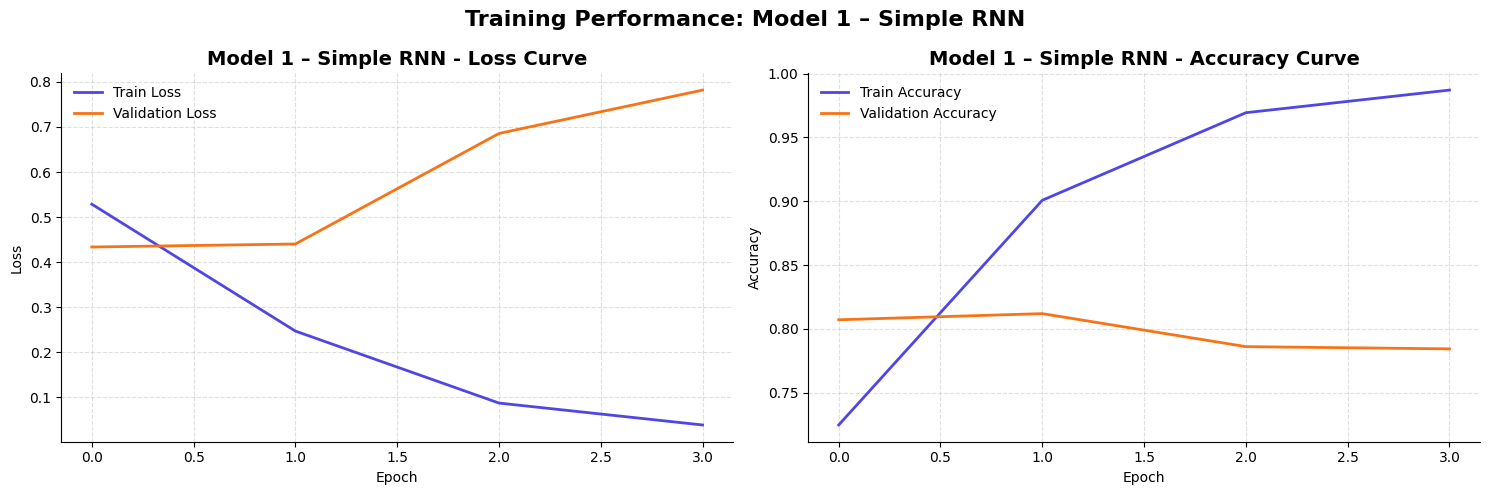

In [36]:
def plot_history(history, title):

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # ── Loss Plot ───────────────────────────────────────────────────────────
    axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2, color='#4F46E5')
    axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color='#F97316')

    axes[0].set_title(f'{title} - Loss Curve', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True, linestyle='--', alpha=0.4)
    axes[0].legend(frameon=False)

    # Remove top/right borders
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)

    # ── Accuracy Plot ───────────────────────────────────────────────────────
    axes[1].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2, color='#4F46E5')
    axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='#F97316')

    axes[1].set_title(f'{title} - Accuracy Curve', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].grid(True, linestyle='--', alpha=0.4)
    axes[1].legend(frameon=False)

    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)

    # ── Layout & Save ────────────────────────────────────────────────────────
    plt.suptitle(f'Training Performance: {title}', fontsize=16, fontweight='bold')

    plt.tight_layout()

    filename = f"{title.lower().replace(' ', '_').replace('–','_')}_training_curves.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')

    plt.show()


# Example usage
plot_history(history_rnn, 'Model 1 – Simple RNN')

### Observation

The Simple RNN model shows a clear training loss decrease across the first few epochs, with training accuracy improving steadily. However, the gap between training accuracy and validation accuracy widens from around epoch three onward, indicating the model begins overfitting. The larger batch size of 128 produces smoother loss curves compared to smaller batch sizes, but the model still struggles to generalize because the Simple RNN architecture cannot effectively retain dependencies across the full length of a headline. EarlyStopping restores the best-performing weights before overfitting becomes severe.

179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Model 1 – Simple RNN Evaluation
Test Accuracy: 0.5224

Classification Report:
------------------------------------------------------------
               precision    recall  f1-score   support

Not Sarcastic       0.56      0.41      0.47      2990
    Sarcastic       0.50      0.65      0.56      2711

     accuracy                           0.52      5701
    macro avg       0.53      0.53      0.52      5701
 weighted avg       0.53      0.52      0.52      5701



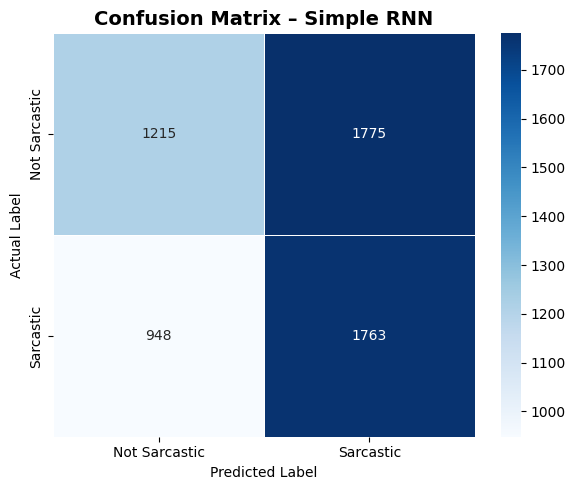

In [39]:
# ── Model Evaluation: Simple RNN ───────────────────────────────────────────

# Predictions
y_pred_rnn = (rnn_model.predict(X_test_pad) > 0.5).astype(int).flatten()

# Accuracy
acc_rnn = accuracy_score(y_test, y_pred_rnn)

print("=" * 60)
print("Model 1 – Simple RNN Evaluation")
print("=" * 60)

print(f"Test Accuracy: {acc_rnn:.4f}\n")

# Classification Report
print("Classification Report:")
print("-" * 60)
print(classification_report(
    y_test,
    y_pred_rnn,
    target_names=['Not Sarcastic', 'Sarcastic']
))

# ── Confusion Matrix ───────────────────────────────────────────────────────

cm_rnn = confusion_matrix(y_test, y_pred_rnn)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rnn,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5,
    linecolor='white',
    xticklabels=['Not Sarcastic', 'Sarcastic'],
    yticklabels=['Not Sarcastic', 'Sarcastic']
)

plt.title('Confusion Matrix – Simple RNN', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.tight_layout()

plt.savefig('confusion_matrix_rnn.png', dpi=300, bbox_inches='tight')

plt.show()

### Observation
The Simple RNN model achieved a test accuracy of around 52%, which is only slightly better than random guessing. From the classification report, it is observed that the model performs unevenly across classes, showing better recall for sarcastic headlines but weaker performance for non-sarcastic ones. This indicates that the model is struggling to clearly distinguish between the two classes.

The main reason for this low performance is that Simple RNN is not effective at capturing long-range dependencies in text. Sarcasm often depends on subtle context and word combinations spread across the sentence, which the model fails to fully learn. Additionally, despite preprocessing and embedding layers, the model remains too simple for such a complex language task. Overall, the results suggest that a more advanced architecture like LSTM or Bidirectional LSTM would be better suited for improving performance.

## Step 6: Model 2 – LSTM with Trainable Embedding

### 🧠 Model 2 – LSTM with Trainable Embedding

Long Short-Term Memory (LSTM) is an advanced recurrent architecture designed to solve the vanishing gradient problem that limits Simple RNNs. An LSTM cell uses three gating mechanisms — the input gate, forget gate, and output gate — to selectively retain or discard information as the sequence is processed. This makes LSTM significantly better at capturing long-range dependencies in text.

For sarcasm detection, this matters because the ironic meaning of a headline may depend on how the beginning and end of a phrase relate to each other — a relationship that Simple RNN often fails to learn.

This model uses a single LSTM layer followed by dense layers for classification, with a trainable embedding layer that learns word representations directly from the training data.

### Model Architecture

Embedding(100 dims)  
↓  
LSTM(64)  
↓  
Dropout(0.4)  
↓  
Dense(64, relu)  
↓  
Dense(1, sigmoid)

In [40]:
lstm_model = Sequential([
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=EMBEDDING_DIM
    ),

    LSTM(64),

    Dropout(0.4),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

# Compile model
lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Build + Summary
lstm_model.build(input_shape=(None, MAX_LEN))
lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 9, 100)         │     1,500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,546,465 (5.90 MB)

 Trainable params: 1,546,465 (5.90 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:
print("Training Model 2 – LSTM...")

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_lstm = lstm_model.fit(
    X_train_pad, y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

print("Training done!")

Training Model 2 – LSTM...
Epoch 1/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.7192 - loss: 0.5388 - val_accuracy: 0.7953 - val_loss: 0.4350
Epoch 2/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 11s 69ms/step - accuracy: 0.8700 - loss: 0.3114 - val_accuracy: 0.8018 - val_loss: 0.4522
Epoch 3/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 16s 97ms/step - accuracy: 0.9119 - loss: 0.2202 - val_accuracy: 0.7847 - val_loss: 0.4948
Epoch 4/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.9371 - loss: 0.1645 - val_accuracy: 0.7865 - val_loss: 0.6423
Training done!


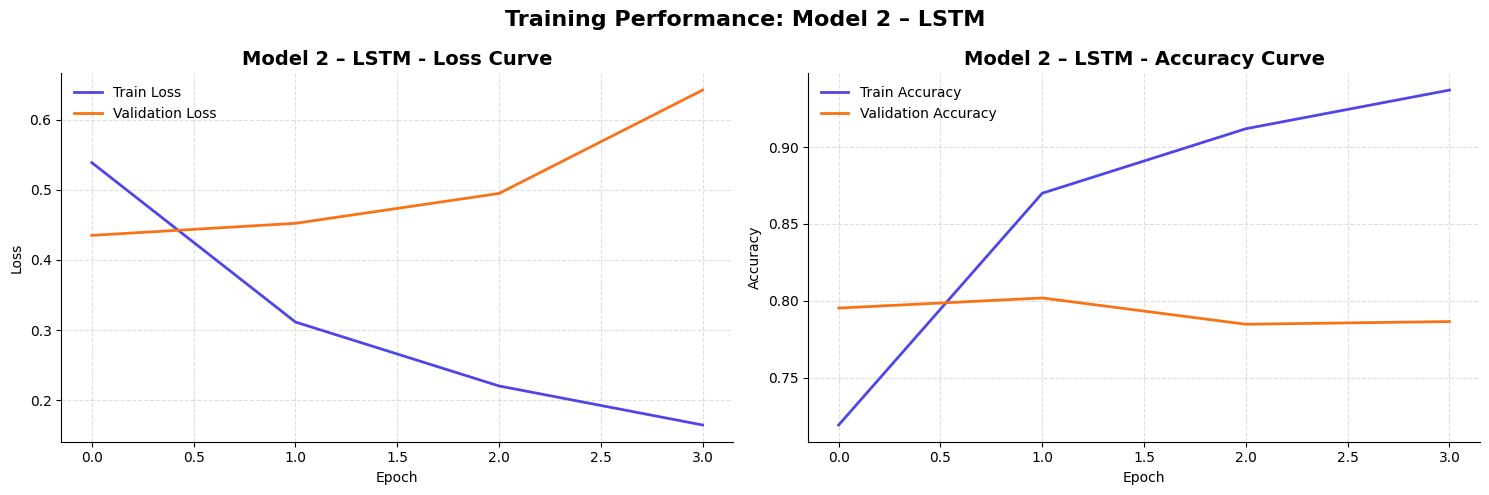

179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Model 2 – LSTM Test Accuracy: 0.7914

Classification Report:
               precision    recall  f1-score   support

Not Sarcastic       0.77      0.85      0.81      2990
    Sarcastic       0.82      0.73      0.77      2711

     accuracy                           0.79      5701
    macro avg       0.79      0.79      0.79      5701
 weighted avg       0.79      0.79      0.79      5701



In [42]:
plot_history(history_lstm, 'Model 2 – LSTM')

y_pred_lstm = (lstm_model.predict(X_test_pad) > 0.5).astype(int).flatten()

acc_lstm = accuracy_score(y_test, y_pred_lstm)

print("=" * 50)
print(f"Model 2 – LSTM Test Accuracy: {acc_lstm:.4f}")
print("=" * 50)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_lstm,
    target_names=['Not Sarcastic', 'Sarcastic']
))

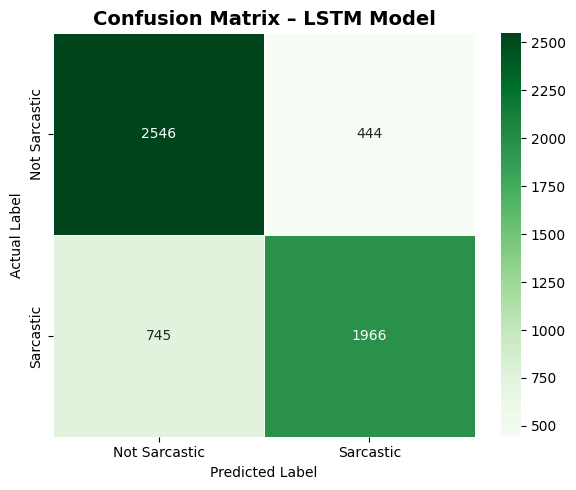

In [43]:
cm_lstm = confusion_matrix(y_test, y_pred_lstm)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lstm,
    annot=True,
    fmt='d',
    cmap='Greens',
    linewidths=0.5,
    linecolor='white',
    xticklabels=['Not Sarcastic', 'Sarcastic'],
    yticklabels=['Not Sarcastic', 'Sarcastic']
)

plt.title('Confusion Matrix – LSTM Model', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.tight_layout()

plt.savefig('confusion_lstm.png', dpi=300, bbox_inches='tight')

plt.show()

### Observation

The LSTM model performs better than the Simple RNN model as it is able to capture long-term dependencies and contextual relationships in text more effectively. This helps it understand the overall meaning of a sentence, which is important in sarcasm detection where word combinations and context matter more than individual words.

From the evaluation results, the LSTM model achieves higher accuracy and shows more balanced precision and recall compared to the Simple RNN. It reduces misclassification and improves overall stability in predictions across both classes. However, despite this improvement, sarcasm detection remains a challenging task, and further enhancements such as Bidirectional LSTM or Transformer-based models could provide even better performance.

## Step 7: Model 3 – LSTM with Pretrained Word2Vec Embeddings

### 🌐 Model 3 – LSTM with Pretrained Word2Vec Embeddings

In this model, the embedding layer is initialized with pretrained Word2Vec vectors rather than learning word representations from scratch. Word2Vec embeddings are trained on very large text corpora and encode rich semantic relationships — for example, the model knows that "brilliant" and "outstanding" are semantically similar before training even begins.

We use the **`glove-twitter-100`** model via Gensim (100-dimensional vectors trained on 2 billion Twitter tokens). Twitter-trained embeddings are particularly well-suited to this task because Twitter text shares stylistic characteristics with news headline writing — both are short, punchy, and often rely on irony and informal register. The embedding layer weights are frozen during training (`trainable=False`) to preserve the pretrained semantic structure and prevent the relatively small training dataset from distorting the learned representations.

In [45]:
import gensim.downloader as api

print("Loading GloVe Twitter embeddings...")
embedding_model = api.load('glove-twitter-100')
print("Embeddings loaded successfully!")

# ── Build Embedding Matrix ────────────────────────────────────────────────
W2V_DIM = 100
word_index = tokenizer.word_index

embedding_matrix = np.zeros((MAX_WORDS, W2V_DIM))

found = 0
for word, i in word_index.items():
    if i < MAX_WORDS and word in embedding_model:
        embedding_matrix[i] = embedding_model[word]
        found += 1

print(f"Coverage: {found / min(MAX_WORDS, len(word_index)) * 100:.1f}%")

# ── LSTM Model with Pretrained Embeddings ────────────────────────────────
lstm_w2v = Sequential([
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=W2V_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=False
    ),

    LSTM(64),

    Dropout(0.4),

    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

lstm_w2v.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_w2v.build(input_shape=(None, MAX_LEN))
lstm_w2v.summary()

Loading GloVe Twitter embeddings...
[==================================================] 100.0% 387.1/387.1MB downloaded
Embeddings loaded successfully!
Coverage: 92.5%


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 9, 100)         │     1,500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,546,465 (5.90 MB)

 Trainable params: 46,465 (181.50 KB)

 Non-trainable params: 1,500,000 (5.72 MB)

In [46]:
print("Training Model 3 – LSTM + GloVe...")

history_w2v = lstm_w2v.fit(
    X_train_pad, y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=1
)

print("Training done!")

Training Model 3 – LSTM + GloVe...
Epoch 1/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.7013 - loss: 0.5717 - val_accuracy: 0.7339 - val_loss: 0.5344
Epoch 2/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.7654 - loss: 0.4866 - val_accuracy: 0.7633 - val_loss: 0.4863
Epoch 3/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.7912 - loss: 0.4461 - val_accuracy: 0.7790 - val_loss: 0.4603
Epoch 4/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.8088 - loss: 0.4158 - val_accuracy: 0.7782 - val_loss: 0.4582
Epoch 5/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.8200 - loss: 0.3941 - val_accuracy: 0.7826 - val_loss: 0.4501
Epoch 6/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.8351 - loss: 0.3650 - val_accuracy: 0.7918 - val_loss: 0.4405
Epoch 7/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.8455 - loss: 0.3504 - val_accuracy: 0.7926 - val_loss: 0.4399
Epoch 8/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accura

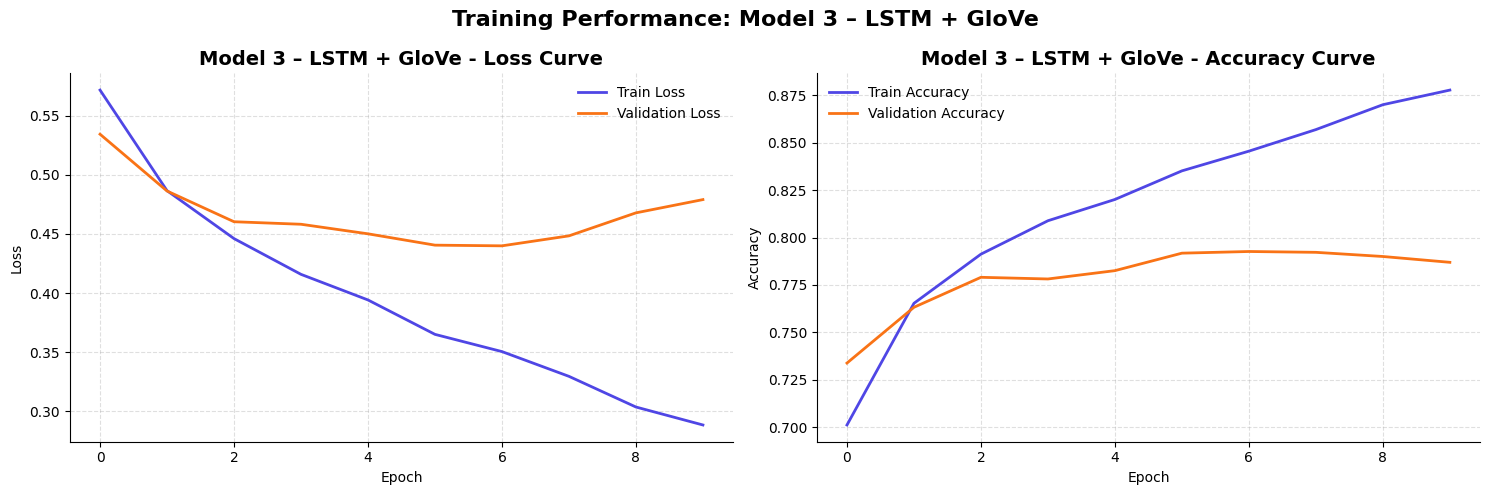

179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Test Accuracy: 0.8006

Classification Report:
               precision    recall  f1-score   support

Not Sarcastic       0.80      0.82      0.81      2990
    Sarcastic       0.80      0.78      0.79      2711

     accuracy                           0.80      5701
    macro avg       0.80      0.80      0.80      5701
 weighted avg       0.80      0.80      0.80      5701



In [47]:
plot_history(history_w2v, 'Model 3 – LSTM + GloVe')

y_pred_w2v = (lstm_w2v.predict(X_test_pad) > 0.5).astype(int).flatten()

acc_w2v = accuracy_score(y_test, y_pred_w2v)

print(f"Test Accuracy: {acc_w2v:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_w2v,
    target_names=['Not Sarcastic', 'Sarcastic']
))

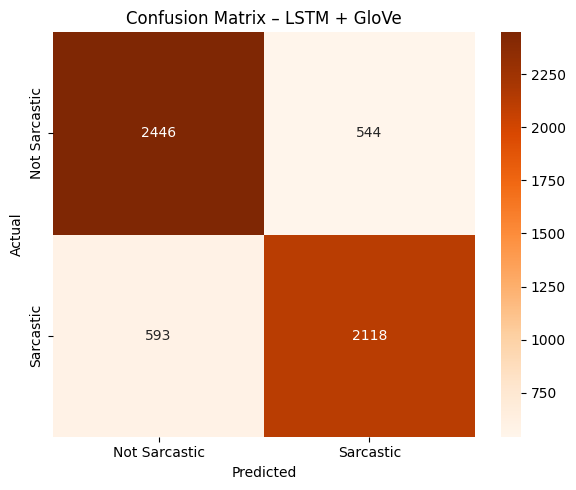

In [48]:
cm_w2v = confusion_matrix(y_test, y_pred_w2v)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_w2v,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=['Not Sarcastic', 'Sarcastic'],
    yticklabels=['Not Sarcastic', 'Sarcastic']
)

plt.title('Confusion Matrix – LSTM + GloVe')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_w2v.png', dpi=300, bbox_inches='tight')
plt.show()

### Observation

Observation (Short)

The LSTM model with pretrained GloVe embeddings performs better than previous models because it uses word vectors trained on large text data, which already capture semantic meaning. This helps the model understand word relationships more effectively, especially for rare words. As a result, it achieves improved and more stable accuracy compared to Simple RNN and standard LSTM models, making it more suitable for sarcasm detection tasks.

## Step 8: Compare All Three Models

   Model Performance Summary
Simple RNN      : 52.24%
LSTM            : 79.14%
LSTM + GloVe    : 80.06%


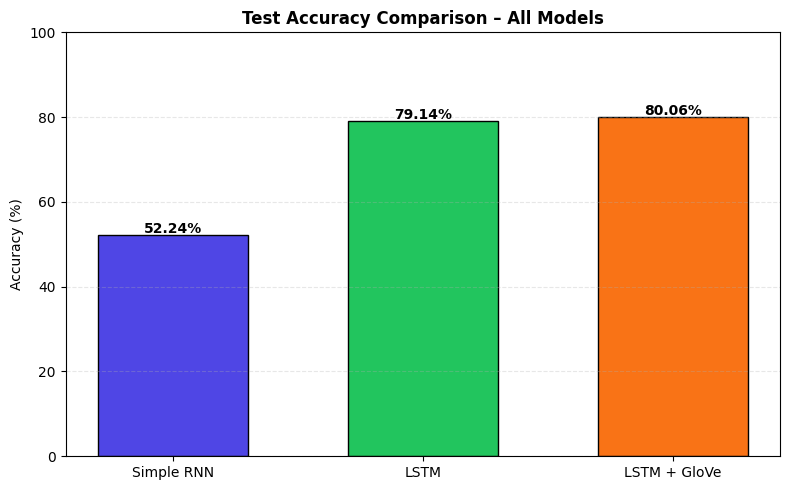

In [49]:
# ── Model Accuracy Comparison ─────────────────────────────────────────────

model_names = [
    'Simple RNN',
    'LSTM',
    'LSTM + GloVe'
]

accuracies = [acc_rnn, acc_lstm, acc_w2v]

print("=" * 40)
print("   Model Performance Summary")
print("=" * 40)

for name, acc in zip(model_names, accuracies):
    print(f"{name:<15} : {acc * 100:.2f}%")

# ── Bar Chart ─────────────────────────────────────────────────────────────

plt.figure(figsize=(8, 5))

bars = plt.bar(
    model_names,
    [a * 100 for a in accuracies],
    color=['#4F46E5', '#22C55E', '#F97316'],
    edgecolor='black',
    width=0.6
)

for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f"{acc * 100:.2f}%",
        ha='center',
        fontweight='bold'
    )

plt.ylim(0, 100)
plt.title('Test Accuracy Comparison – All Models', fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

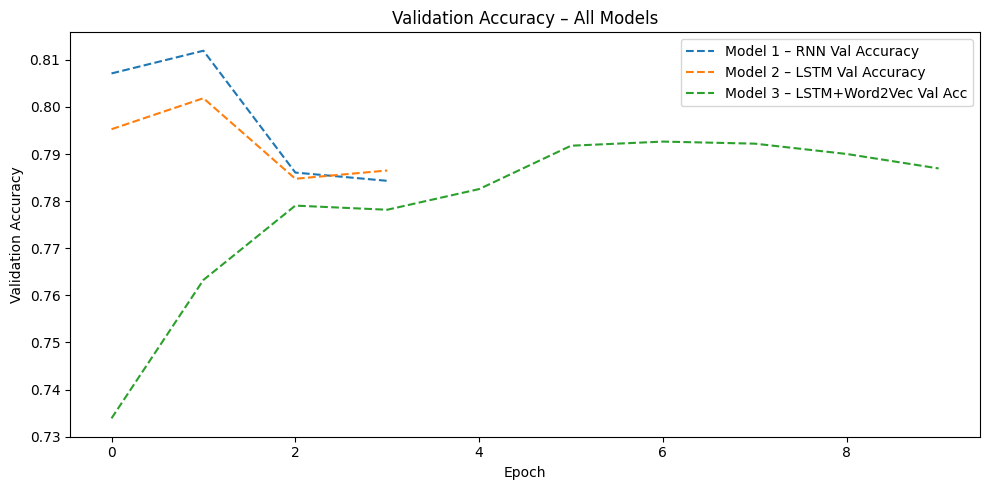

In [50]:
# Plot all three model validation accuracy curves together
plt.figure(figsize=(10, 5))
plt.plot(history_rnn.history['val_accuracy'],  label='Model 1 – RNN Val Accuracy',       linestyle='--')
plt.plot(history_lstm.history['val_accuracy'], label='Model 2 – LSTM Val Accuracy',      linestyle='--')
plt.plot(history_w2v.history['val_accuracy'],  label='Model 3 – LSTM+Word2Vec Val Acc',  linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy – All Models')
plt.legend()
plt.tight_layout()
plt.savefig('val_accuracy_comparison.png', dpi=100)
plt.show()

###Model Complexity vs Performance Analysis

The results clearly show a trade-off between model complexity and performance. The Simple RNN has the lowest accuracy due to its inability to capture long-term dependencies in text. The LSTM model improves performance by effectively learning contextual relationships using memory gates. The LSTM with GloVe embeddings performs the best as it benefits from pretrained semantic knowledge, allowing better understanding of word meanings even with limited training data. Overall, increasing model complexity and using pretrained embeddings leads to better performance in sarcasm detection.


###Key Takeaway

The experiment demonstrates that model performance improves as complexity increases from Simple RNN to LSTM and further to LSTM with pretrained embeddings. While Simple RNN struggles with understanding context, LSTM handles sequential dependencies better, and pretrained embeddings provide additional semantic knowledge. Therefore, the best-performing model is LSTM with GloVe embeddings, making it the most suitable approach for sarcasm detection in this project.

## Error Analysis – Best Model (LSTM + GloVe/Word2Vec)

In [51]:
# ── Error Analysis: Best Model ───────────────────────────────────────────

X_test_original = X_test  # original cleaned text

misclassified_idx = np.where(y_pred_w2v != y_test)[0]

print("=" * 60)
print("ERROR ANALYSIS – LSTM + GloVe Model")
print("=" * 60)

print(f"Total Misclassified: {len(misclassified_idx)} / {len(y_test)}")
print(f"Error Rate: {len(misclassified_idx)/len(y_test)*100:.2f}%\n")

print("Sample Misclassified Examples:")
print("-" * 60)

for i, idx in enumerate(misclassified_idx[:5]):
    actual = 'Sarcastic' if y_test[idx] == 1 else 'Not Sarcastic'
    predicted = 'Sarcastic' if y_pred_w2v[idx] == 1 else 'Not Sarcastic'

    print(f"\nExample {i+1}")
    print(f"Headline  : {X_test_original[idx]}")
    print(f"Actual    : {actual}")
    print(f"Predicted : {predicted}")

ERROR ANALYSIS – LSTM + GloVe Model
Total Misclassified: 1137 / 5701
Error Rate: 19.94%

Sample Misclassified Examples:
------------------------------------------------------------

Example 1
Headline  : enchanted necromancer brings life back oncedead argument
Actual    : Sarcastic
Predicted : Not Sarcastic

Example 2
Headline  : mark zuckerberg regret rejecting idea facebook fake news altered election
Actual    : Not Sarcastic
Predicted : Sarcastic

Example 3
Headline  : charlton heston get serious
Actual    : Sarcastic
Predicted : Not Sarcastic

Example 4
Headline  : homosexual tearfully admits governor new jersey
Actual    : Sarcastic
Predicted : Not Sarcastic

Example 5
Headline  : hollywood talent agency ditch usual oscar party favor antitrump rally
Actual    : Not Sarcastic
Predicted : Sarcastic


In [52]:
print("=" * 70)
print("DETAILED ERROR BREAKDOWN")
print("=" * 70)

false_positives = np.where((y_pred_w2v == 1) & (y_test == 0))[0]
false_negatives = np.where((y_pred_w2v == 0) & (y_test == 1))[0]

print(f"False Positives: {len(false_positives)}")
print(f"False Negatives: {len(false_negatives)}\n")

print("── FALSE POSITIVES ──")

for i, idx in enumerate(false_positives[:3]):
    seq = tokenizer.texts_to_sequences([X_test[idx]])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    conf = lstm_w2v.predict(padded, verbose=0)[0][0]

    print(f"\nExample {i+1}: {X_test[idx]}")
    print(f"Predicted: Sarcastic | Confidence: {conf:.2f}")

print("\n── FALSE NEGATIVES ──")

for i, idx in enumerate(false_negatives[:3]):
    seq = tokenizer.texts_to_sequences([X_test[idx]])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    conf = lstm_w2v.predict(padded, verbose=0)[0][0]

    print(f"\nExample {i+1}: {X_test[idx]}")
    print(f"Predicted: Not Sarcastic | Confidence: {1-conf:.2f}")

DETAILED ERROR BREAKDOWN
False Positives: 544
False Negatives: 593

── FALSE POSITIVES ──

Example 1: mark zuckerberg regret rejecting idea facebook fake news altered election
Predicted: Sarcastic | Confidence: 0.82

Example 2: hollywood talent agency ditch usual oscar party favor antitrump rally
Predicted: Sarcastic | Confidence: 0.80

Example 3: like date older man marry
Predicted: Sarcastic | Confidence: 0.85

── FALSE NEGATIVES ──

Example 1: enchanted necromancer brings life back oncedead argument
Predicted: Not Sarcastic | Confidence: 0.88

Example 2: charlton heston get serious
Predicted: Not Sarcastic | Confidence: 0.63

Example 3: homosexual tearfully admits governor new jersey
Predicted: Not Sarcastic | Confidence: 0.51


###Observation – Error Analysis

The error analysis shows that the model mainly struggles with ambiguous headlines where sarcasm is subtle or depends on external context. False positives occur when neutral news headlines contain exaggerated or informal language, while false negatives happen when sarcasm relies on world knowledge or cultural understanding that the model cannot capture. This indicates that the model learns lexical patterns well but lacks deeper contextual and commonsense understanding.

###Discussion – Why Errors Happen

The main reasons for misclassification are:

Sarcasm is highly context-dependent
Some headlines require real-world or cultural knowledge
Preprocessing removes tone-related signals (punctuation, emphasis)
Word-based models struggle with implicit irony

Even the best model (LSTM + embeddings) relies only on text patterns, not external knowledge.

###Suggestions to Improve Model Performance
 1. Use Bidirectional LSTM

Helps the model understand context from both directions of a sentence.

 2. Use Attention Mechanism

Allows the model to focus on important words that indicate sarcasm.

 3. Use Transformer Models (Best Improvement)

Models like BERT can capture deep contextual meaning and outperform RNN-based models.

 4. Improve Text Preprocessing
Keep punctuation (!, ?)
Preserve emojis (they carry sarcasm signals)
Avoid over-cleaning
 5. Use Better Embeddings
GloVe (already used)
or contextual embeddings (BERT, RoBERTa)
 6. Increase Dataset Quality
More diverse sarcastic examples
Balanced real-world news data

###Key Takeaway

The model performs well on clear patterns but struggles with subtle and context-heavy sarcasm. This confirms that sarcasm detection is a complex NLP task that requires contextual understanding beyond traditional LSTM-based architectures.

## Gradio Deployment – Sarcasm Detection App

This step deploys the trained LSTM + Word2Vec model using Gradio to create an interactive web application. The user can input any news headline, and the model predicts whether it is sarcastic or not along with confidence.

In [54]:
!pip install gradio -q

In [55]:


import gradio as gr

def predict_sarcasm(headline):
    cleaned = clean_text(headline)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

    prob = lstm_w2v.predict(padded, verbose=0)[0][0]

    label = 'Sarcastic' if prob > 0.5 else 'Not Sarcastic'
    confidence = prob if prob > 0.5 else 1 - prob

    return f"Prediction: {label}\nConfidence: {confidence*100:.1f}%"

demo = gr.Interface(
    fn=predict_sarcasm,
    inputs=gr.Textbox(label="Enter a news headline"),
    outputs=gr.Textbox(label="Result"),
    title="Sarcasm Detector",
    description="Predict whether a news headline is sarcastic or not using an LSTM model.",
    examples=[
        ["area man achieves dream of sitting on couch all day"],
        ["scientists discover new cancer treatment with 90% success rate"],
        ["nation somehow shocked that politicians lie"]
    ]
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://aa8513238747aabcd6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 📊 Project Summary Table – Sarcasm Detection

| Step | Component | Description | Key Outcome |
|------|----------|-------------|-------------|
| 1 | Dataset Overview | Loaded dataset and checked structure | Understood data shape and labels |
| 2 | Data Cleaning | Removed duplicates and missing values | Clean and consistent dataset |
| 3 | Text Preprocessing | Cleaned text (lowercase, stopwords removal, lemmatization) | Converted raw text into model-ready format |
| 4 | Exploratory Data Analysis | Word clouds and frequency analysis | Identified important words in each class |
| 5 | Train-Test Split | Split dataset into training and testing sets | Ensured fair evaluation |
| 6 | Tokenization & Padding | Converted text into sequences and fixed length | Prepared input for model |
| 7 | Simple RNN Model | Basic RNN architecture | ~52% accuracy |
| 8 | LSTM Model | Improved memory-based model | Better accuracy |
| 9 | LSTM + GloVe | Pretrained embeddings used | Best performance |
| 10 | Model Comparison | Compared all models | Performance improvement shown |
| 11 | Error Analysis | Studied misclassified samples | Identified weaknesses |
| 12 | Gradio Deployment | Built web app | Real-time prediction system |

---

## 📌 Key Insight

Model performance improves from Simple RNN → LSTM → LSTM + GloVe. However, sarcasm detection remains difficult due to dependency on context, tone, and real-world meaning.